# EDA: цены на авиабилеты

## Цель

Исследовать кэшированные ценовые предложения Aviasales Data API / Travelpayouts
по выбранным внутренним маршрутам России.

Данные собраны 3 октября 2026 года. После обработки в анализ вошло
305 предложений по 41 маршруту с фактическими датами вылета
с 9 октября 2026 года по 31 января 2027 года.

## Исследовательские вопросы

1. Как различаются цены на билеты туда-обратно между маршрутами?
2. Как связаны цена, количество пересадок и длительность поездки?
3. Как меняется цена в зависимости от времени до вылета?
4. Какие ограничения выборки влияют на интерпретацию результатов?

## Данные

- Источник: Aviasales Data API / Travelpayouts.
- Единица наблюдения: одно доступное кэшированное ценовое предложение на билет туда-обратно.
- В исходной выгрузке: 368 API-ответов.
- В подготовленной таблице: 305 валидных предложений.
- Маршрутов с данными: 41.
- Валюта: российские рубли.

## Ограничения

- Данные являются кэшированными предложениями API, а не фактическими бронированиями или продажами.
- Анализ основан на одной выгрузке, выполненной 3 октября 2026 года.
- 63 из 368 API-ответов не содержали подходящего предложения.
- Покрытие маршрутов и горизонтов бронирования неравномерно: отдельные маршруты имеют от 4 до 8 наблюдений.
- API может вернуть фактическую дату вылета, отличающуюся от запрошенной, поэтому в анализе используются фактические даты и объединённые горизонты бронирования.
- Выводы относятся только к доступной выборке и не являются универсальным рейтингом цен на авиабилеты в России.

In [79]:
from pathlib import Path

import pandas as pd


PROJECT_ROOT = Path.cwd().parents[0]
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "flight_prices_2026-10-03.csv"

flights = pd.read_csv(DATA_PATH)

print(f"Строк: {len(flights)}")
print(f"Столбцов: {flights.shape[1]}")
display(flights.head()) 

Строк: 305
Столбцов: 28


,route,origin,destination_requested,destination_returned,collected_at,requested_departure_at,departure_at,departure_date,departure_weekday,departure_hour,...,transfers,is_direct,duration,duration_hours,duration_to,duration_to_hours,duration_back,duration_back_hours,expires_at,source_file
0,KZN -> AER,KZN,AER,AER,2026-10-03 00:00:00+00:00,2026-10-10 00:00:00+00:00,2026-10-10 18:50:00+00:00,2026-10-10,Saturday,18,...,1,False,1250,20.83,340,5.67,195,3.25,2026-10-03 19:26:57+00:00,expanded_flight_prices_2026-10-03.jsonl
1,KZN -> AER,KZN,AER,AER,2026-10-03 00:00:00+00:00,2026-10-17 00:00:00+00:00,2026-10-17 11:35:00+00:00,2026-10-17,Saturday,11,...,0,True,400,6.67,205,3.42,195,3.25,2026-10-03 19:26:59+00:00,expanded_flight_prices_2026-10-03.jsonl
2,KZN -> AER,KZN,AER,AER,2026-10-03 00:00:00+00:00,2026-10-24 00:00:00+00:00,2026-10-24 09:35:00+00:00,2026-10-24,Saturday,9,...,0,True,420,7.00,225,3.75,195,3.25,2026-10-03 19:26:59+00:00,expanded_flight_prices_2026-10-03.jsonl
3,KZN -> AER,KZN,AER,AER,2026-10-03 00:00:00+00:00,2026-11-02 00:00:00+00:00,2026-11-02 11:20:00+00:00,2026-11-02,Monday,11,...,1,False,3860,64.33,315,5.25,315,5.25,2026-10-03 19:27:01+00:00,expanded_flight_prices_2026-10-03.jsonl
4,KZN -> AER,KZN,AER,AER,2026-10-03 00:00:00+00:00,2026-11-17 00:00:00+00:00,2026-11-17 11:50:00+00:00,2026-11-17,Tuesday,11,...,0,True,1765,29.42,215,3.58,270,4.50,2026-10-03 19:27:02+00:00,expanded_flight_prices_2026-10-03.jsonl


In [80]:
flights.info()


<class 'pandas.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   route                   305 non-null    str    
 1   origin                  305 non-null    str    
 2   destination_requested   305 non-null    str    
 3   destination_returned    305 non-null    str    
 4   collected_at            305 non-null    str    
 5   requested_departure_at  305 non-null    str    
 6   departure_at            305 non-null    str    
 7   departure_date          305 non-null    str    
 8   departure_weekday       305 non-null    str    
 9   departure_hour          305 non-null    int64  
 10  return_at               305 non-null    str    
 11  return_date             305 non-null    str    
 12  days_ahead              305 non-null    int64  
 13  days_before_departure   305 non-null    int64  
 14  price                   305 non-null    int64  
 15  

In [81]:
quality_check = pd.DataFrame(
    {
        "dtype": flights.dtypes.astype(str),
        "missing_values": flights.isna().sum(),
        "missing_share_pct": (
            flights.isna().mean() * 100
        ).round(2),
        "unique_values": flights.nunique(),
    }
).sort_values(
    ["missing_values", "unique_values"],
    ascending=[False, True],
)

display(quality_check)

,dtype,missing_values,missing_share_pct,unique_values
collected_at,str,0,0.0,1
currency,str,0,0.0,1
source_file,str,0,0.0,1
is_direct,bool,0,0.0,2
transfers,int64,0,0.0,3
origin,str,0,0.0,5
departure_weekday,str,0,0.0,7
requested_departure_at,str,0,0.0,8
days_ahead,int64,0,0.0,8
destination_requested,str,0,0.0,9


In [82]:
print("Полных дупликатов:", flights.duplicated().sum())

print(
    "Дубликатов по ключу "
    "(маршрут, вылет, перевозчик, пересадки, цена):",
    flights.duplicated(
        subset=[
            "route",
            "departure_at",
            "return_at",
            "airline",
            "transfers",
            "price",
        ]
    ).sum(),
)

print(
    "\nДиапазон дат вылета:",
    flights["departure_date"].min(),
    "-",
    flights["departure_date"].max(),
)

print(
    "Диапазон дней до вылета:",
    flights["days_before_departure"].min(),
    "-",
    flights["days_before_departure"].max(),
)

print(
    "Диапазон цен:",
    f"{flights['price'].min():,.0f}",
    "-",
    f"{flights['price'].max():,.0f}",
    "RUB",
)


Полных дупликатов: 0
Дубликатов по ключу (маршрут, вылет, перевозчик, пересадки, цена): 0

Диапазон дат вылета: 2026-10-09 - 2027-01-31
Диапазон дней до вылета: 6 - 120
Диапазон цен: 4,480 - 43,772 RUB


In [83]:
price_summary = flights["price"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]
)

display(price_summary.to_frame(name="price_rub"))

,price_rub
count,305.000000
mean,15154.698361
std,5708.371159
min,4480.000000
25%,10666.000000
50%,14593.000000
75%,18605.000000
90%,22512.200000
95%,24928.400000
max,43772.000000


In [84]:
datetime_columns = [
    "collected_at",
    "requested_departure_at",
    "departure_at",
    "return_at",
    "expires_at",
]

for column in datetime_columns:
    flights[column] = pd.to_datetime(
        flights[column],
        errors="coerce",
        utc=True,
    )

flights["departure_date"] = pd.to_datetime(
    flights["departure_date"],
    errors="coerce",
)

flights["return_date"] = pd.to_datetime(
    flights["return_date"],
    errors="coerce",
)

flights.info()
 

<class 'pandas.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   route                   305 non-null    str                
 1   origin                  305 non-null    str                
 2   destination_requested   305 non-null    str                
 3   destination_returned    305 non-null    str                
 4   collected_at            305 non-null    datetime64[us, UTC]
 5   requested_departure_at  305 non-null    datetime64[us, UTC]
 6   departure_at            305 non-null    datetime64[us, UTC]
 7   departure_date          305 non-null    datetime64[us]     
 8   departure_weekday       305 non-null    str                
 9   departure_hour          305 non-null    int64              
 10  return_at               305 non-null    datetime64[us, UTC]
 11  return_date             305 non-null    datetime64[us]  

In [85]:
route_coverage = (
    flights.groupby("route", as_index=False)
    .agg(
        offers=("price", "size"),
        min_price_rub=("price", "min"),
        median_price_rub=("price", "median"),
        max_price_rub=("price", "max"),
        direct_share_pct=("is_direct", lambda x: (x.mean() *100).round(1)),
    )
    .sort_values(
        ["offers", "median_price_rub"],
        ascending=[True, True],
    )
)

display(route_coverage)

,route,offers,min_price_rub,median_price_rub,max_price_rub,direct_share_pct
39,SVX -> TJM,4,24592,28411.5,43772,0.0
4,KZN -> OVB,5,17073,17332.0,20218,100.0
7,KZN -> UFA,6,4480,6395.5,11240,100.0
32,OVB -> UFA,6,15742,16974.5,25451,66.7
6,KZN -> TJM,6,16858,18066.5,20206,16.7
19,MOW -> LED,7,5410,5442.0,9561,100.0
2,KZN -> LED,7,7600,8300.0,14819,85.7
40,SVX -> UFA,7,7201,8422.0,9613,100.0
23,MOW -> TJM,7,9464,9667.0,19748,100.0
24,MOW -> UFA,7,8246,9736.0,12984,100.0


In [86]:
transfer_summary = (
    flights.groupby(
        ["transfers", "is_direct"],
        as_index=False,
    )
    .agg(
        offers=("price", "size"),
        median_price_rub=("price", "median"),
        mean_price_rub=("price", "mean"),
        min_price_rub=("price", "min"),
        max_price_rub=("price", "max"),
        median_duration_hours=("duration_hours", "median"),
    )
)

transfer_summary["offer_share_pct"] = (
    transfer_summary["offers"]
    / len(flights)
    *100
).round(1)

display(transfer_summary)

,transfers,is_direct,offers,median_price_rub,mean_price_rub,min_price_rub,max_price_rub,median_duration_hours,offer_share_pct
0,0,True,253,13776.0,14200.316206,4480,28960,6.25,83.0
1,1,False,51,18686.0,19744.274510,12415,43772,32.92,16.7
2,2,False,1,22545.0,22545.000000,22545,22545,43.08,0.3


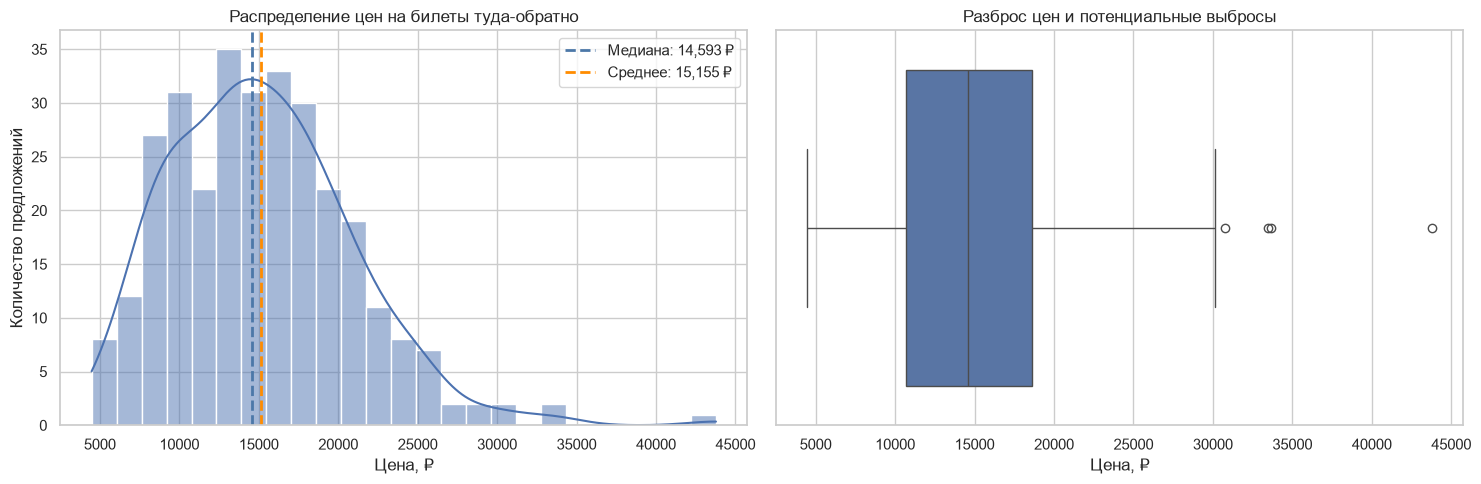

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
)

sns.histplot(
    data=flights,
    x="price",
    bins=25,
    kde=True,
    ax=axes[0],
)

axes[0].axvline(
    flights["price"].median(),
    color="#4C78A8",
    linestyle="--",
    linewidth=2,
    label=f"Медиана: {flights['price'].median():,.0f} ₽",
)

axes[0].axvline(
    flights["price"].mean(),
    color="darkorange",
    linestyle="--",
    linewidth=2,
    label=f"Среднее: {flights['price'].mean():,.0f} ₽",
)

axes[0].set_title("Распределение цен на билеты туда-обратно")
axes[0].set_xlabel("Цена, ₽")
axes[0].set_ylabel("Количество предложений")
axes[0].legend()

sns.boxplot(
    data=flights,
    x="price",
    ax=axes[1],
)

axes[1].set_title("Разброс цен и потенциальные выбросы")
axes[1].set_xlabel("Цена, ₽")

plt.tight_layout()
plt.show()

### Распределение цен

Распределение цен на билеты туда-обратно имеет умеренную правостороннюю асимметрию. Большинство наблюдений сосредоточено примерно в диапазоне от 10 000 до 20 000 ₽.

Медианная цена составляет 14 593 ₽, а средняя — 15 155 ₽. Средняя цена немного выше медианы, что объясняется наличием нескольких дорогих предложений. Максимальная цена в выборке составляет 43 772 ₽.

На boxplot видны отдельные потенциальные выбросы в верхней части диапазона. На данном этапе они не удаляются автоматически: дорогие предложения могут быть реальными и отражать особенности маршрута, даты вылета, длительности поездки или наличия пересадок. Их влияние будет дополнительно проверено в разрезе маршрутов.

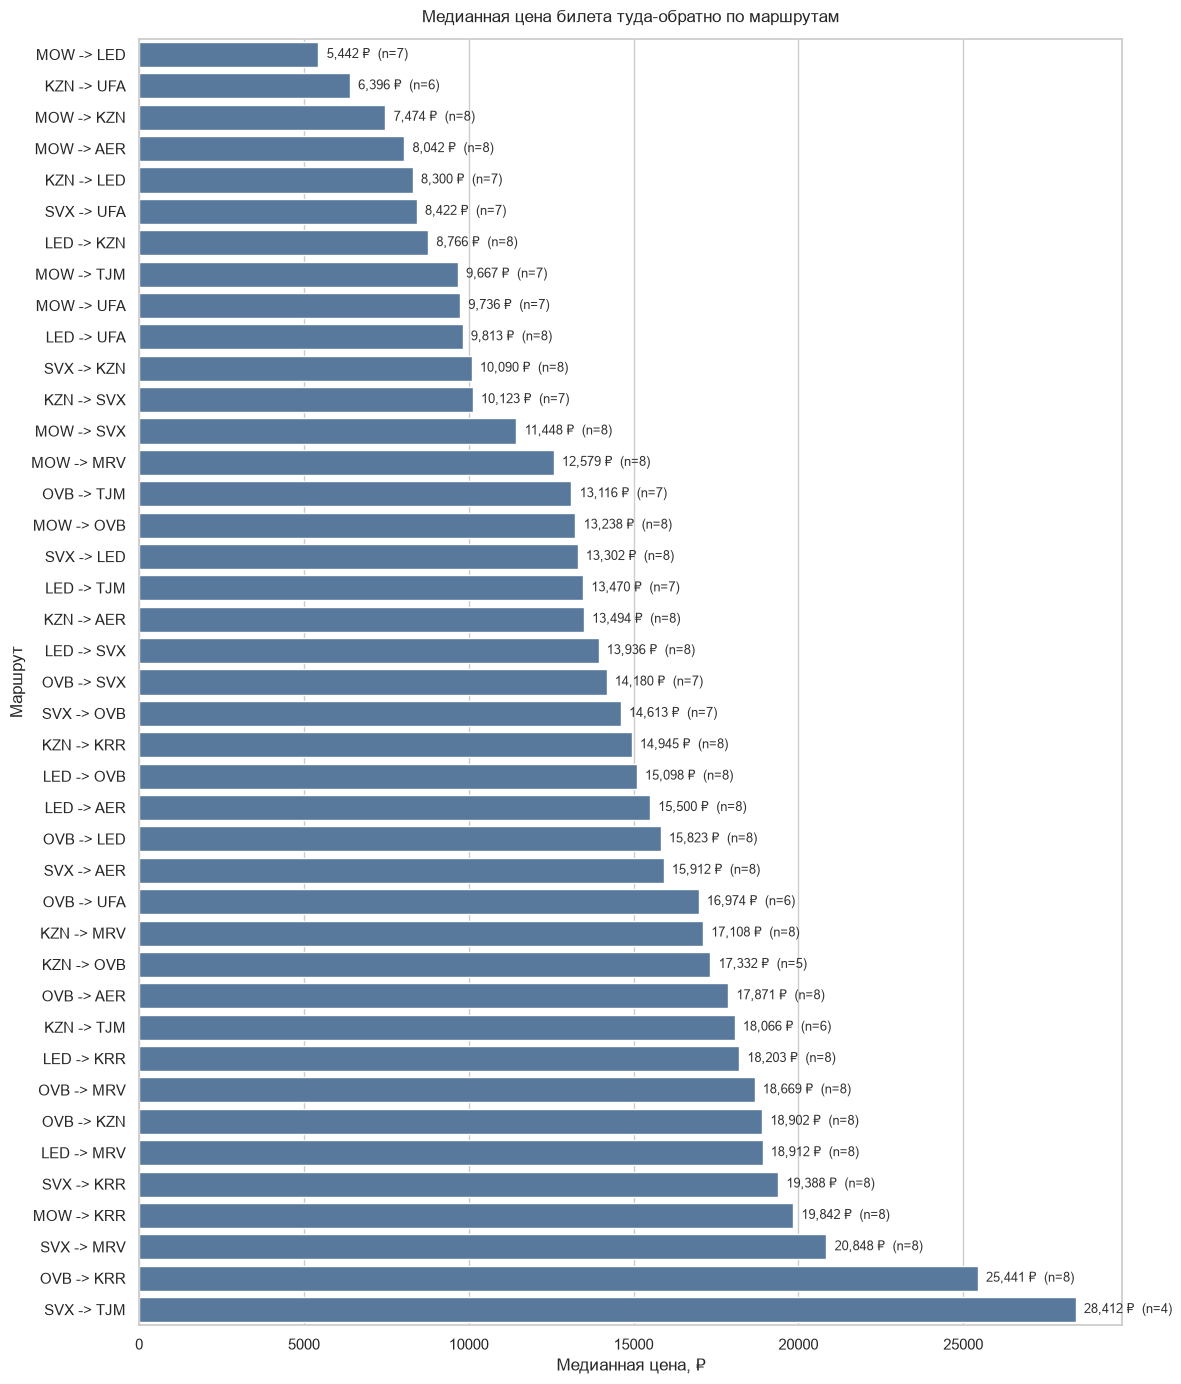

In [88]:
route_plot = (
    route_coverage
    .sort_values("median_price_rub", ascending=True)
    .copy()
)

plt.figure(figsize=(12, 14))

sns.barplot(
    data=route_plot,
    x="median_price_rub",
    y="route",
    color="#4C78A8",
)

plt.title(
    "Медианная цена билета туда-обратно по маршрутам",
    pad=12,
)
plt.xlabel("Медианная цена, ₽")
plt.ylabel("Маршрут")

for index, row in route_plot.reset_index(drop=True).iterrows():
    plt.text(
        row["median_price_rub"] + 250,
        index,
        f"{row['median_price_rub']:,.0f} ₽  (n={row['offers']})",
        va="center",
        fontsize=9,
        color="#333333",
    )

plt.tight_layout()
plt.show()

### Медианная цена по маршрутам

Медианная цена билета туда-обратно заметно различается между маршрутами. В нашей выборке самый низкий показатель наблюдается для направления MOW → LED — около 5 442 ₽, а самый высокий — для SVX → TJM — около 28 412 ₽.

При интерпретации необходимо учитывать объём данных. Для SVX → TJM доступно только четыре наблюдения, поэтому результат является ориентировочным. Более устойчиво выглядят маршруты с восемью наблюдениями, например OVB → KRR с медианной ценой около 25 441 ₽.

График показывает цены только по выбранным маршрутам, датам вылета и кэшированным ответам API. Поэтому он не является универсальным рейтингом стоимости авиабилетов по России.

In [89]:
plot_data = flights.copy()

plot_data["transfer_category"] = plot_data["transfers"].map(
    {
        0: "0 - прямой рейс",
        1: "1 пересадка",
        2: "2 пересадки",
    }
)

transfer_order = [
    "0 - прямой рейс",
    "1 пересадка",
    "2 пересадки",
]

transfer_counts = (
    plot_data["transfer_category"]
    .value_counts()
    .reindex(transfer_order)
)

display(transfer_counts.to_frame(name="offers"))

,offers
transfer_category,
0 - прямой рейс,253
1 пересадка,51
2 пересадки,1


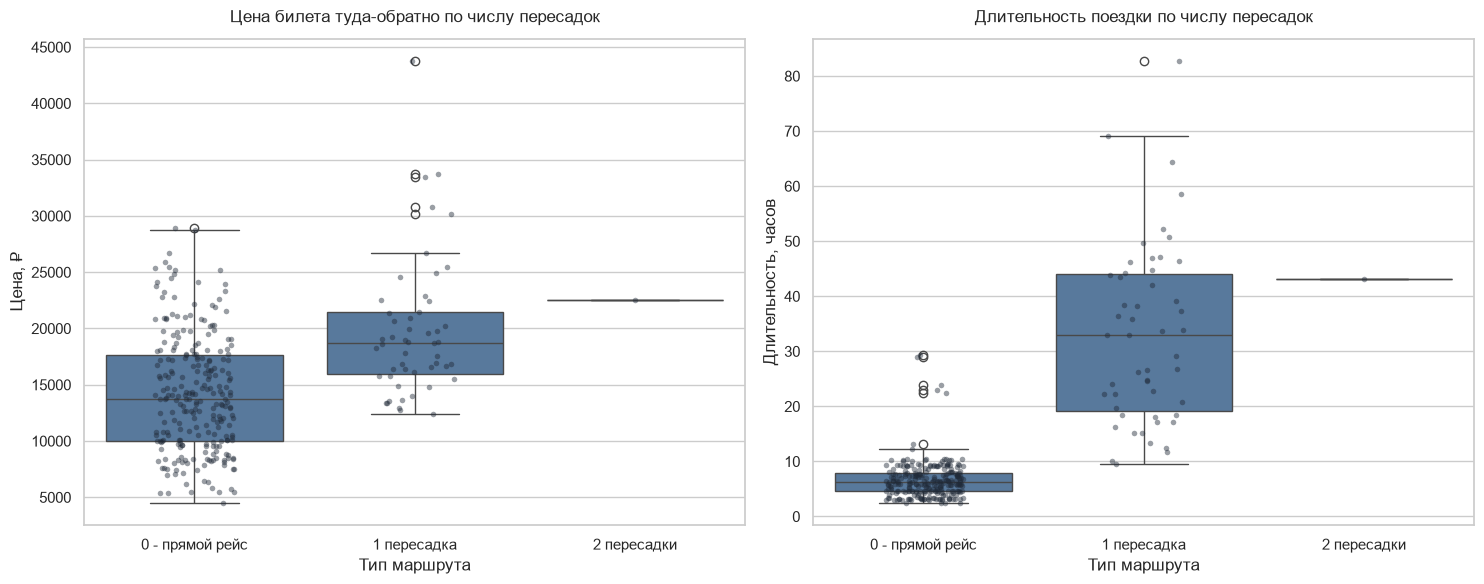

In [90]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6),
)

sns.boxplot(
    data=plot_data,
    x="transfer_category",
    y="price",
    order=transfer_order,
    color="#4C78A8",
    ax=axes[0],
)

axes[0].set_title(
    "Цена билета туда-обратно по числу пересадок",
    pad=12,
)
axes[0].set_xlabel("Тип маршрута")
axes[0].set_ylabel("Цена, ₽")

sns.stripplot(
    data=plot_data,
    x="transfer_category",
    y="price",
    order=transfer_order,
    color="#1F2937",
    alpha=0.45,
    size=4,
    jitter=0.18,
    ax=axes[0],
)

sns.boxplot(
    data=plot_data,
    x="transfer_category",
    y="duration_hours",
    order=transfer_order,
    color="#4C78A8",
    ax=axes[1],
)

axes[1].set_title(
    "Длительность поездки по числу пересадок",
    pad=12,
)
axes[1].set_xlabel("Тип маршрута")
axes[1].set_ylabel("Длительность, часов")

sns.stripplot(
    data=plot_data,
    x="transfer_category",
    y="duration_hours",
    order=transfer_order,
    color="#1F2937",
    alpha=0.45,
    size=4,
    jitter=0.18,
    ax=axes[1],
)

plt.tight_layout()
plt.show()

In [91]:
transfer_report = (
    plot_data.groupby(
        "transfer_category",
        observed=False,
    )
    .agg(
        offers=("price", "size"),
        offer_share_pct=(
            "price",
            lambda x: round(len(x) / len(plot_data) *100, 1),
        ),
        median_price_rub=("price", "median"),
        mean_price_rub=("price", "mean"),
        median_duration_hours=("duration_hours", "median"),
        mean_duration_hours=("duration_hours", "mean"),
    )
    .reindex(transfer_order)
)

display(transfer_report)

,offers,offer_share_pct,median_price_rub,mean_price_rub,median_duration_hours,mean_duration_hours
transfer_category,,,,,,
0 - прямой рейс,253,83.0,13776.0,14200.316206,6.25,6.653478
1 пересадка,51,16.7,18686.0,19744.274510,32.92,32.826078
2 пересадки,1,0.3,22545.0,22545.000000,43.08,43.080000


### Цена и длительность в зависимости от пересадок

В выборке преобладают прямые варианты: 253 из 305 предложений, или 83,0%. Предложения с одной пересадкой составляют 16,7% выборки, а варианты с двумя пересадками представлены только одним наблюдением.

Медианная цена прямого варианта составляет 13 776 ₽, а варианта с одной пересадкой — 18 686 ₽. Одновременно медианная длительность поездки увеличивается с 6,25 часа для прямых рейсов до 32,92 часа для маршрутов с одной пересадкой.

Следовательно, в рамках данной выборки пересадка не связана с экономией: варианты с одной пересадкой чаще дороже и существенно длиннее. Однако это наблюдательная связь, а не доказательство причинности: пересадки могут быть характерны для отдельных, более дальних или менее обеспеченных прямыми рейсами направлений. Категория с двумя пересадками не интерпретируется из-за одного наблюдения.

In [ ]:
days_summary = (
    flights.groupby(
        "days_before_departure",
        as_index=False,
    )
    .agg(
        offers=("price", "size"),
        median_price_rub=("price", "median"),
        mean_price_rub=("price", "mean"),
        min_price_rub=("price", "min"),
        max_price_rub=("price", "max"),
        routes=("route", "nunique"),
    )
    .sort_values("days_before_departure")
)

display(days_summary)

In [ ]:
fig, ax = plt.subplots(
    figsize=(13, 6),
)

sns.lineplot(
    data=days_summary,
    x="days_before_departure",
    y="median_price_rub",
    marker="o",
    color="#4C78A8",
    linewidth=2.5,
    markersize=8,
    ax=ax,
)

ax.set_title(
    "Медианная цена билета в зависимостях от времени до вылета",
    pad=12,
    fontsize=14,
)

ax.set_xlabel("Дней до вылета")
ax.set_ylabel("Медианная цена, ₽")

ax.set_xticks(days_summary["days_before_departure"])
ax.set_xticklabels(
    days_summary["days_before_departure"],
    rotation=75,
    ha="right",
)

ax.grid(
    axis="y",
    alpha=0.3,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)




plt.tight_layout()
plt.show()

### Цена и время до вылета

In [ ]:
route_medians = (
    flights.groupby("route")["price"]
    .median()
    .rename("route_median_price_rub")
)

normalized_prices = flights.merge(
    route_medians,
    on="route",
    how="left",
)

normalized_prices["price_vs_route_median_pct"] = (
    normalized_prices["price"]
    / normalized_prices["route_median_price_rub"]
    *100
)

normalized_days_summary = (
    normalized_prices.groupby(
        "days_before_departure",
        as_index=False,
    )
    .agg(
        offers=("price", "size"),
        routes=("route", "nunique"),
        median_price_vs_route_median_pct=(
            "price_vs_route_median_pct",
            "median",
        ),
    mean_price_vs_route_median_pct=(
        "price_vs_route_median_pct",
        "mean",
        ),
    )
    .sort_values("days_before_departure")
)

display(normalized_days_summary)

In [ ]:
fig, ax = plt.subplots(
    figsize=(13, 6),
)

sns.lineplot(
    data=normalized_days_summary,
    x="days_before_departure",
    y="median_price_vs_route_median_pct",
    marker="o",
    color="#4C78A8",
    linewidth=2.5,
    markersize=8,
    ax=ax,
)

ax.axhline(
    100,
    color="#D62728",
    linestyle="--",
    linewidth=1.5,
    label="100% — медиана маршрута",
)

ax.set_title(
    "Цена относительно типичной цены маршрута\n"
    "в зависимости от времени до вылета",
    pad=14,
    fontsize=14,
)

ax.set_xlabel("Дней до вылета")
ax.set_ylabel("Цена относительно медианы маршрута, %")

ax.set_xticks(
    normalized_days_summary["days_before_departure"]
)

ax.set_xticklabels(
    normalized_days_summary["days_before_departure"],
    rotation=45,
    ha="right",
)

ax.grid(
    axis="y",
    alpha=0.3,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend()

plt.tight_layout()
plt.show()

In [96]:
display(
    normalized_days_summary[
        [
            "days_before_departure",
            "offers",
            "routes",
            "median_price_vs_route_median_pct",
        ]
    ].style.format(
        {
            "median_price_vs_route_median_pct": "{:.1f}%",
        }
    )
)

,days_before_departure,offers,routes,median_price_vs_route_median_pct
0,6,5,5,90.5%
1,7,36,36,100.0%
2,13,5,5,99.3%
3,14,36,36,98.4%
4,20,3,3,106.7%
5,21,36,36,101.6%
6,29,3,3,111.2%
7,30,36,36,101.5%
8,44,4,4,115.2%
9,45,36,36,96.6%


In [97]:
def normalize_booking_horizon(days):
    if days <= 7:
        return 7
    if days <= 14:
        return 14
    if days <= 21:
        return 21
    if days <=30:
        return 30
    if days <= 45:
        return 45
    if days <= 60:
        return 60
    if days <= 90:
        return 90
    return 120

flights["booking_horizon"] = flights[
    "days_before_departure"
].apply(normalize_booking_horizon)

horizon_summary = (
    flights.groupby(
        "booking_horizon",
        as_index=False,
    )
    .agg(
        offers=("price", "size"),
        median_price_rub=("price", "median"),
        mean_price_rub=("price", "mean"),
        routes=("route", "nunique")
    )
    .sort_values("booking_horizon")
)

display(horizon_summary)

,booking_horizon,offers,median_price_rub,mean_price_rub,routes
0,7,41,13558.0,14499.463415,41
1,14,41,14346.0,14274.195122,41
2,21,39,15385.0,15465.974359,39
3,30,39,14729.0,14359.794872,39
4,45,40,13817.0,13937.325000,40
5,60,35,13412.0,13266.828571,35
6,90,40,19640.0,19124.200000,40
7,120,30,16210.0,16415.266667,30


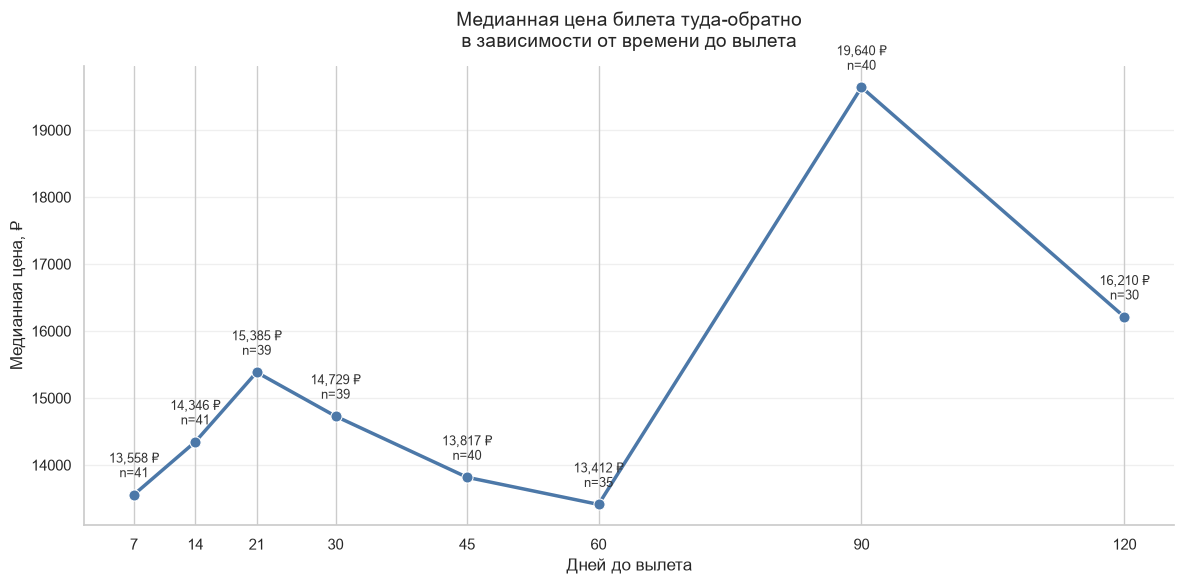

In [98]:
horizon_plot = horizon_summary.copy()

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=horizon_plot,
    x="booking_horizon",
    y="median_price_rub",
    marker="o",
    markersize=8,
    linewidth=2.5,
    color="#4C78A8",
    ax=ax,
)

for _, row in horizon_plot.iterrows():
    ax.annotate(
        (
            f"{row['median_price_rub']:,.0f} ₽\n"
            f"n={int(row['offers'])}"
        ),
        xy=(
            row["booking_horizon"],
            row["median_price_rub"],
        ),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#333333",
    )

ax.set_title(
    "Медианная цена билета туда-обратно\n"
    "в зависимости от времени до вылета",
    pad=14,
    fontsize=14,
)

ax.set_xlabel("Дней до вылета")
ax.set_ylabel("Медианная цена, ₽")

ax.set_xticks(horizon_plot["booking_horizon"])
ax.set_xticklabels(horizon_plot["booking_horizon"])

ax.grid(axis="y", alpha=0.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Цена и время до вылета

Близкие фактические сроки до вылета были объединены в восемь плановых
горизонтов: 7, 14, 21, 30, 45, 60, 90 и 120 дней.

Медианная цена билета туда-обратно не меняется монотонно при увеличении
времени до вылета. На горизонтах от 7 до 60 дней медианная цена находится
примерно в диапазоне от 13 412 ₽ до 15 385 ₽. Наиболее высокая медианная
цена в выборке наблюдается за 90 дней до вылета — 19 640 ₽ при 40
предложениях.

По результатам этой выгрузки нельзя утверждать, что раннее бронирование
всегда дешевле или всегда дороже. На цены могут одновременно влиять маршрут,
сезонность, кэшированная природа API-ответов и неодинаковое покрытие
маршрутов. Для устойчивого вывода нужно регулярно собирать данные по одним
и тем же маршрутам и датам вылета.

# Итоговые выводы

## 1. Данные и качество выборки

- В анализ вошло 305 ценовых предложений по 41 маршруту.
- Данные получены из одной выгрузки Travelpayouts / Aviasales Data API, выполненной 3 октября 2026 года.
- В исходном сборе обработано 368 API-ответов; 63 ответа не содержали подходящих предложений.
- В подготовленной таблице нет пропусков в ключевых полях цены, маршрута и даты вылета, а также не обнаружено полных дубликатов.
- Покрытие маршрутов и горизонтов бронирования неравномерно: для части маршрутов доступно от 4 до 7 наблюдений вместо полного набора из 8.

## 2. Распределение цен

- Цены на билеты туда-обратно в выборке лежат в диапазоне от 4 480 ₽ до 43 772 ₽.
- Медианная цена составляет 14 593 ₽, средняя — 15 155 ₽.
- Центральные 50% предложений находятся в диапазоне от 10 666 ₽ до 18 605 ₽.
- Распределение имеет правостороннюю асимметрию: несколько дорогих предложений формируют длинный правый хвост и повышают среднее значение относительно медианы.
- Высокие значения не удалялись автоматически, поскольку они могут отражать реальные особенности маршрута, дат вылета, длительности или пересадок.

## 3. Различия между маршрутами

- Медианные цены заметно различаются между маршрутами, поэтому маршрут является одним из основных факторов различий в стоимости.
- Самый низкий медианный уровень в выборке наблюдается на маршруте `MOW → LED` — около 5 442 ₽ при 7 наблюдениях.
- Самый высокий медианный уровень наблюдается на маршруте `SVX → TJM` — около 28 412 ₽, однако для него доступно только 4 наблюдения, поэтому этот результат следует интерпретировать осторожно.
- Среди маршрутов с полным покрытием из 8 наблюдений самым дорогим является `OVB → KRR` с медианной ценой около 25 441 ₽.
- Эти значения описывают только выбранные маршруты и доступные кэшированные предложения API, а не являются общим рейтингом стоимости авиабилетов в России.

## 4. Пересадки и длительность

- Прямые рейсы составляют 83,0% выборки: 253 из 305 предложений.
- Варианты с одной пересадкой составляют 16,7% выборки: 51 предложение.
- Варианты с двумя пересадками представлены одним наблюдением, поэтому для них нельзя формулировать устойчивые выводы.
- Для прямых вариантов медианная цена составляет 13 776 ₽, а медианная длительность поездки — 6,25 часа.
- Для вариантов с одной пересадкой медианная цена составляет 18 686 ₽, а медианная длительность — 32,92 часа.
- В рамках данной выборки предложения с одной пересадкой чаще были одновременно дороже и существенно длиннее прямых вариантов.
- Эта связь не доказывает, что пересадка сама по себе повышает цену: она может быть связана с дальностью маршрута, доступностью прямых рейсов и особенностями отдельных направлений.

## 5. Время до вылета

- Фактический срок до вылета в выборке составляет от 6 до 120 дней.
- API иногда возвращал фактическую дату вылета на один день раньше запрошенной даты. Поэтому близкие сроки были объединены в восемь горизонтов бронирования: 7, 14, 21, 30, 45, 60, 90 и 120 дней.
- Наиболее высокая медианная цена в объединённой выборке наблюдается примерно за 90 дней до вылета — около 19 640 ₽.
- Однако полученная зависимость не является монотонной: нельзя утверждать, что раннее бронирование всегда дешевле или всегда дороже.
- Результат по горизонту 90 дней следует интерпретировать осторожно из-за неоднородного состава маршрутов и кэшированной природы API-ответов.
- Сравнение цен относительно медианы каждого маршрута помогает уменьшить влияние изначально дорогих и дешёвых направлений, но не устраняет ограничение одной даты сбора.

## 6. Ограничения и дальнейшие шаги

- API возвращает кэшированные предложения, а не фактические продажи или бронирования.
- Выгрузка выполнена в один день, поэтому нельзя изучить динамику цен во времени сбора.
- Не все комбинации маршрут × дата вернули предложение.
- Для более надёжного исследования нужно выполнять сбор регулярно, например ежедневно или еженедельно, и накапливать наблюдения по одинаковым маршрутам и датам.
- Следующий логичный этап проекта — автоматизировать регулярный сбор, добавить временной ряд цен и подготовить итоговое описание результатов в `README.md`.